### Student Information
Name:黃裕傑

Student ID:114232501

GitHub ID:eng-jack


---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

Import and Check Enviroment


In [43]:

# envirronment setup
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.feature_extraction.text import CountVectorizer
import helpers.data_mining_helpers as dmh
import sys
%load_ext autoreload
%autoreload 2
print(sys.executable) # my path
print(sys.version) #3.13.4

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\jack\AppData\Local\Programs\Python\Python313\python.exe
3.13.4 (tags/v3.13.4:8a526ec, Jun  3 2025, 17:46:04) [MSC v.1943 64 bit (AMD64)]


Data Preparation:
    read csv file and show 0-9
    

In [44]:
Reddit = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')

Reddit.head(10)

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0
9,comment,2021-12-31 16:29:49,hqp3kt4,stockstobuytoday,Any cheap stocks under $10?,Zumuru,https://www.reddit.com/r/stockstobuytoday/comm...,2,NaN,NaN,HLGN is $10. Hurry and catch it now before it ...,0.000000,0.000000,0.0,"['HLGN', 'Hurry', 'moon']",1.0


In [45]:
Reddit[::100]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
100,comment,2025-04-11 15:01:48,mmknyf6,StockMarket,The Trump administration is begging Xi Jinping...,Darkstar197,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,Do we have a copy of trump’s kindergarten grad...,0.400000,-0.050000,-1.0,"['certificate', 'version', 'form', '’', 'trump...",-1.0
200,comment,2025-04-11 14:42:17,mmkk04x,StockMarket,Trump: We Are Doing Really Well On Our Tariff ...,coochellamai,https://i.redd.it/uajqu4kxl7ue1.png,1,NaN,NaN,I need people to understand this man is NOT st...,0.604242,-0.260227,-1.0,"['plan', 'goal', 'man', 'USD', 'US', 'economy'...",1.0
300,comment,2022-04-23 20:11:55,i5x0o24,stockstobuytoday,Technical Analysis Thread.,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,[/](/),0.000000,0.000000,0.0,"['/', ']']",0.0
400,comment,2025-04-11 14:30:36,mmkhog3,StockMarket,"Trump is surrounded by a bunch of idiots, he s...",gonzo0815,https://i.redd.it/c2mmpy3qf7ue1.png,1,NaN,NaN,Imo it's bullshit for another reason: why woul...,0.391667,0.016667,1.0,"['reason', 'anything', 'relation', 'point', 'g...",-1.0
500,comment,2025-04-11 14:27:20,mmkh0uf,StockMarket,The Trump administration is begging Xi Jinping...,Bloodsucker_,https://edition.cnn.com/2025/04/10/politics/tr...,-2,NaN,NaN,Everyone is talking about the Bond market. But...,0.500000,0.000000,0.0,"['year', 'bond', 'everyone', 'market', 'Bond',...",0.0
600,comment,2025-04-11 13:55:11,mmkaotn,wallstreetbets,Weekly Earnings Thread 4/14 - 4/18,grhotz,https://i.redd.it/b51iqmecn7ue1.jpeg,2,NaN,NaN,Bank week is so boring. PUTS on NFLX,1.000000,-1.000000,-1.0,"['week', 'Bank', 'NFLX', 'Bank week']",-1.0
700,comment,2025-04-12 1:09:59,mmntum6,wallstreetbets,Retail giant TARGET has now declined for 10 co...,CuttyAllgood,https://i.redd.it/7tl6puv9waue1.jpeg,36,NaN,NaN,Donno why you’re getting downvoted. You’re not...,0.900000,-0.500000,-1.0,"['Donno', 'IMO']",1.0
800,comment,2025-04-11 15:27:34,mmkt7j7,stocks,Is the market in complete denial right now?,Vlistorito,https://www.reddit.com/r/stocks/comments/1jwo1...,4,NaN,NaN,"It's a pretty unremarkable product, but you wo...",0.625000,0.333333,1.0,"['information', 'distributor', 'product', 'com...",0.0


In [46]:
print(Reddit.columns)
Reddit.info()

Index(['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url',
       'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity',
       'polarity', 'sentiment', 'entities', 'label'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          847 non-null    object 
 1   datetime      847 non-null    object 
 2   post_id       847 non-null    object 
 3   subreddit     847 non-null    object 
 4   title         847 non-null    object 
 5   author        847 non-null    object 
 6   url           847 non-null    object 
 7   upvotes       847 non-null    int64  
 8   downvotes     64 non-null     float64
 9   upvote_ratio  64 non-null     float64
 10  text          847 non-null    object 
 11  subjectivity  847 non-null    float64
 12  polarity      847 non-null    float64
 13  sentiment     847 non

In [47]:
Reddit[::100]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
100,comment,2025-04-11 15:01:48,mmknyf6,StockMarket,The Trump administration is begging Xi Jinping...,Darkstar197,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,Do we have a copy of trump’s kindergarten grad...,0.400000,-0.050000,-1.0,"['certificate', 'version', 'form', '’', 'trump...",-1.0
200,comment,2025-04-11 14:42:17,mmkk04x,StockMarket,Trump: We Are Doing Really Well On Our Tariff ...,coochellamai,https://i.redd.it/uajqu4kxl7ue1.png,1,NaN,NaN,I need people to understand this man is NOT st...,0.604242,-0.260227,-1.0,"['plan', 'goal', 'man', 'USD', 'US', 'economy'...",1.0
300,comment,2022-04-23 20:11:55,i5x0o24,stockstobuytoday,Technical Analysis Thread.,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,[/](/),0.000000,0.000000,0.0,"['/', ']']",0.0
400,comment,2025-04-11 14:30:36,mmkhog3,StockMarket,"Trump is surrounded by a bunch of idiots, he s...",gonzo0815,https://i.redd.it/c2mmpy3qf7ue1.png,1,NaN,NaN,Imo it's bullshit for another reason: why woul...,0.391667,0.016667,1.0,"['reason', 'anything', 'relation', 'point', 'g...",-1.0
500,comment,2025-04-11 14:27:20,mmkh0uf,StockMarket,The Trump administration is begging Xi Jinping...,Bloodsucker_,https://edition.cnn.com/2025/04/10/politics/tr...,-2,NaN,NaN,Everyone is talking about the Bond market. But...,0.500000,0.000000,0.0,"['year', 'bond', 'everyone', 'market', 'Bond',...",0.0
600,comment,2025-04-11 13:55:11,mmkaotn,wallstreetbets,Weekly Earnings Thread 4/14 - 4/18,grhotz,https://i.redd.it/b51iqmecn7ue1.jpeg,2,NaN,NaN,Bank week is so boring. PUTS on NFLX,1.000000,-1.000000,-1.0,"['week', 'Bank', 'NFLX', 'Bank week']",-1.0
700,comment,2025-04-12 1:09:59,mmntum6,wallstreetbets,Retail giant TARGET has now declined for 10 co...,CuttyAllgood,https://i.redd.it/7tl6puv9waue1.jpeg,36,NaN,NaN,Donno why you’re getting downvoted. You’re not...,0.900000,-0.500000,-1.0,"['Donno', 'IMO']",1.0
800,comment,2025-04-11 15:27:34,mmkt7j7,stocks,Is the market in complete denial right now?,Vlistorito,https://www.reddit.com/r/stocks/comments/1jwo1...,4,NaN,NaN,"It's a pretty unremarkable product, but you wo...",0.625000,0.333333,1.0,"['information', 'distributor', 'product', 'com...",0.0


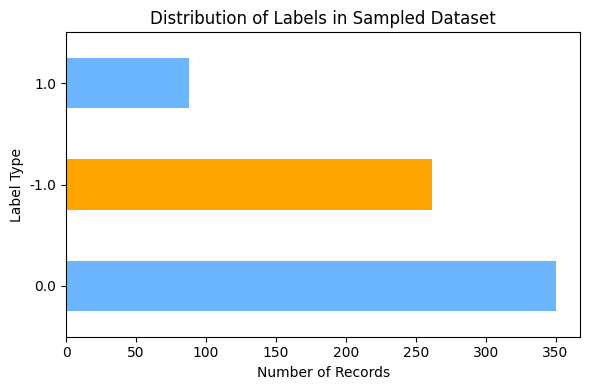

In [48]:
# 從原始 DataFrame 中隨機抽樣 700 筆資料
# 使用 sample() 的 frac 參數可以避免直接指定數字，看起來更自然
df_subset = df.sample(frac=700/len(df), random_state=42)

# 顯示前幾筆確認抽樣結果
df_subset.head(3)

# 統計各標籤(label)出現次數
label_count = df_subset['label'].value_counts()

# 以水平條狀圖顯示每種分類的筆數
ax = label_count.plot(
    kind='barh',
    color=['#6CB6FF', '#FFA500'],
    figsize=(6, 4),
    title='Distribution of Labels in Sampled Dataset'
)
ax.set_xlabel('Number of Records')
ax.set_ylabel('Label Type')

# 顯示圖表
plt.tight_layout()
plt.show()


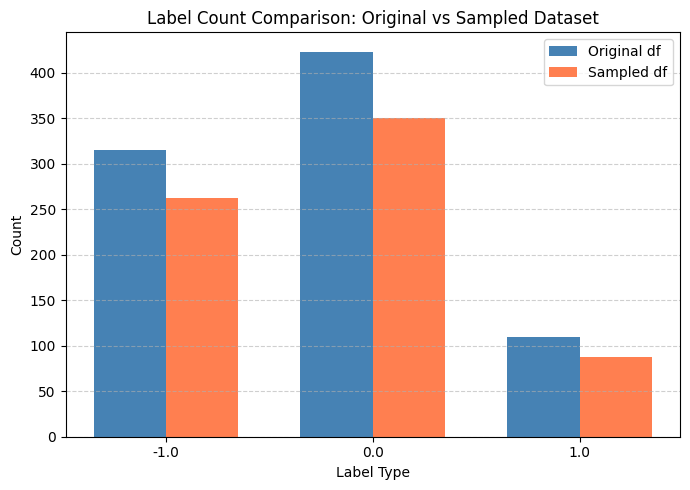

In [49]:
# EX8 Compare label distributions between df and df_sample
import matplotlib.pyplot as plt
import numpy as np

# 計算各資料集的 label 統計
count_full = df['label'].value_counts().sort_index()
count_sample = df_sample['label'].value_counts().sort_index()

# 建立 x 軸位置與柱寬
labels = count_full.index.astype(str)
x_pos = np.arange(len(labels))
width = 0.35

# 繪圖
plt.figure(figsize=(7, 5))
plt.bar(x_pos - width/2, count_full, width=width, color='steelblue', label='Original df')
plt.bar(x_pos + width/2, count_sample, width=width, color='coral', label='Sampled df')

# 標題與軸標籤
plt.title('Label Count Comparison: Original vs Sampled Dataset')
plt.xlabel('Label Type')
plt.ylabel('Count')
plt.xticks(x_pos, labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [50]:

import nltk
from sklearn.feature_extraction.text import CountVectorizer

# 確保分詞器已安裝
nltk.download('punkt', quiet=True)

# 初始化文字向量化器
vectorizer = CountVectorizer(tokenizer=nltk.word_tokenize)

# 將文字欄位轉換為詞頻矩陣
X_bow = vectorizer.fit_transform(df['text'])

# 顯示第二筆文件的向量結果
print("Vector representation of document index 1:")
print(X_bow[1])


Vector representation of document index 1:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 26 stored elements and shape (1, 4534)>
  Coords	Values
  (0, 3839)	1
  (0, 484)	1
  (0, 2146)	2
  (0, 2431)	1
  (0, 4399)	1
  (0, 1274)	1
  (0, 4003)	1
  (0, 1522)	1
  (0, 2525)	1
  (0, 267)	1
  (0, 635)	1
  (0, 1189)	1
  (0, 272)	2
  (0, 3771)	1
  (0, 2283)	1
  (0, 3993)	1
  (0, 1684)	1
  (0, 3008)	1
  (0, 260)	1
  (0, 2773)	1
  (0, 987)	1
  (0, 3620)	1
  (0, 1525)	2
  (0, 3939)	1
  (0, 3048)	1
  (0, 41)	1


c:\Users\jack\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [54]:

# 取得 CountVectorizer 內建的文字分析函式
text_analyzer = vectorizer.build_analyzer()

# 分析第二筆文件的 tokens
sample_text = df.loc[1, 'text']
tokens = text_analyzer(sample_text)

# 印出結果（只顯示前 25 個 token）
print("Tokens extracted from document index 1:")
print(tokens[:25])


print(tokens)



Tokens extracted from document index 1:
['stunt', 'as', 'in', 'like', 'why', 'did', 'they', 'even', 'make', 'a', 'big', 'deal', 'about', 'starting', 'it', 'in', 'the', 'first', 'place', '?', 'no', 'company', 'should', 'ever', 'talk']
['stunt', 'as', 'in', 'like', 'why', 'did', 'they', 'even', 'make', 'a', 'big', 'deal', 'about', 'starting', 'it', 'in', 'the', 'first', 'place', '?', 'no', 'company', 'should', 'ever', 'talk', 'about', 'politics', 'ever', '.']


In [64]:

# EX10 find out where the non-zero elements are
row, col = X_bow[:50,:500].toarray().nonzero()
print(row)
print(col)
vectorizer.get_feature_names_out()[col[10]]


[ 1  1  1  1  1  2  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  4  5  6  6  6  6  6  6  6  6  7  7  7  7  8  8  8  8  8  8  9  9  9
  9  9 10 10 10 11 12 13 13 13 13 13 13 13 13 13 13 13 17 17 17 17 17 17
 17 18 19 19 19 19 19 19 19 19 19 19 19 19 22 22 22 23 23 23 23 23 23 23
 23 24 24 25 25 25 26 26 27 27 28 28 28 28 29 30 30 30 30 30 31 31 31 31
 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31 31
 31 31 31 31 31 31 31 31 31 31 31 32 32 32 34 34 35 35 35 35 35 35 35 36
 36 36 36 36 38 38 39 39 39 39 39 40 40 40 40 41 42 42 44 44 44 44 44 44
 44 44 44 45 45 45 45 46 46 46 46 46 46 46 47 47 47 47 47 48 48 48 48 48
 48 48 48 49 49 49 49]
[ 41 260 267 272 484  41   0  11  15  18  19  20  23  41  83 255 261 263
 267 272 291 292 293 416 423  41  23  23  41  44 267 322 385 423 470  23
  41 119 267   4  41 215 260 267 401   0   2  41  67 423  15  41 267  23
  23   3  23  41  67  95 151 176 201 260 267 443  23  41 124 267 423 440
 484 423  41 267 310 397 401

')'

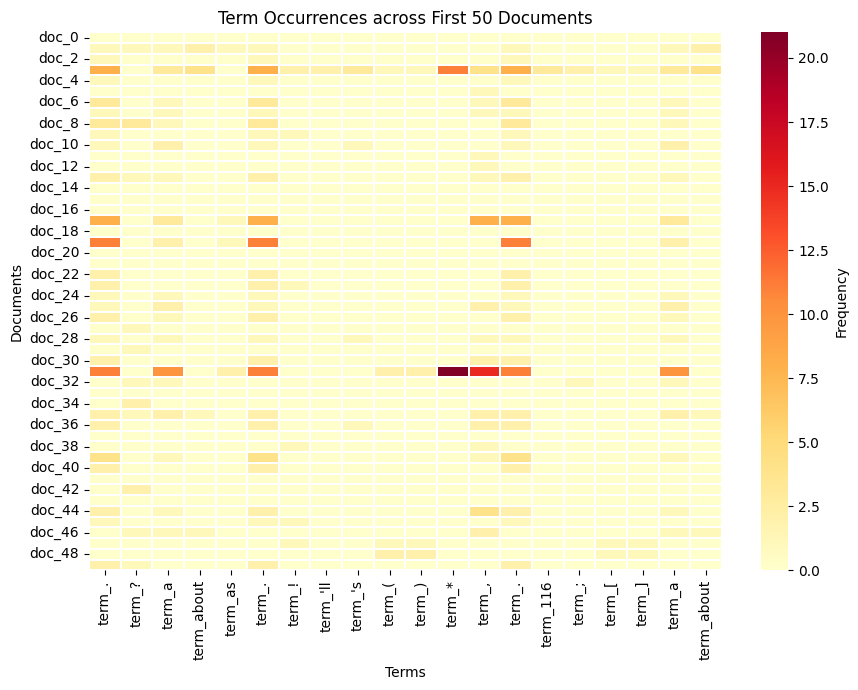

In [66]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 取前 50 篇文件與前 500 個詞
sub_matrix = X_bow[:50, :500].toarray()

# 找出非零元素 (代表該 term 在該文件中出現過)
rows, cols = np.nonzero(sub_matrix)

# 選取前 20 個非零詞的索引（避免圖太擠）
selected_terms_idx = cols[:20]

# 建立 heatmap 對應的軸標籤與數值
x_labels = [f"term_{i}" for i in vectorizer.get_feature_names_out()[selected_terms_idx]]
y_labels = [f"doc_{i}" for i in df.index[:50]]
z_values = X_bow[:50, selected_terms_idx].toarray()

# 建立 DataFrame 並畫 heatmap
heatmap_df = pd.DataFrame(z_values, columns=x_labels, index=y_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Frequency'}
)
plt.title("Term Occurrences across First 50 Documents")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.tight_layout()
plt.show()


In [67]:
term_freq = np.ravel(X_bow.sum(axis=0))

# 檢查第一個詞的出現次數
print("Frequency of the first term:", term_freq[0])

Frequency of the first term: 136


In [71]:
# EX12: Use Plotly to draw the filtered term frequency distribution
import pandas as pd
import plotly.express as px
import re

# 過濾詞彙：只保留「由英文字母或數字組成」的 term
terms = vectorizer.get_feature_names_out()
mask = [bool(re.match(r'^[A-Za-z0-9]+$', t)) for t in terms]
filtered_terms = terms[mask]
filtered_freq = term_freq[mask]

# 取前 300 個符合條件的 term
df_filtered = pd.DataFrame({
    'term': filtered_terms[:300],
    'frequency': filtered_freq[:300]
})

# 畫出互動式長條圖
fig = px.bar(
    df_filtered,
    x='term',
    y='frequency',
    title='Frequency Distribution of English/Alphanumeric Terms (Top 300)',
    labels={'term': 'Term', 'frequency': 'Frequency'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=500
)
fig.show()


In [74]:


# 設定頻率下限，可依需求調整
min_freq = 7

# 找出所有出現次數 >= min_freq 的詞彙索引
valid_idx = np.where(term_freq >= min_freq)[0]

# 建立 DataFrame 並準備繪圖資料
freq_df = pd.DataFrame({
    'term': vectorizer.get_feature_names_out()[valid_idx],
    'frequency': term_freq[valid_idx]
})

# 使用 Plotly 繪製 bar chart
fig = px.bar(
    freq_df,
    x='term',
    y='frequency',
    title=f"Terms with Frequency ≥ {min_freq}",
    labels={'term': 'Term', 'frequency': 'Frequency'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=500
)
fig.show()


In [75]:
# 設定最低出現次數門檻
min_freq = 10
idx = np.where(term_freq >= min_freq)[0]

# 建立 DataFrame 並依頻率排序
term_freq_df = pd.DataFrame({
    'term': vectorizer.get_feature_names_out()[idx],
    'frequency': term_freq[idx]
}).sort_values(by='frequency', ascending=False).reset_index(drop=True)

# 定義前 10% 為 Head，其餘為 Tail
head_cutoff = int(len(term_freq_df) * 0.1)

# 建立圖表
fig = go.Figure()

# Head 區段（前 10%）
fig.add_trace(go.Scatter(
    x=term_freq_df['term'][:head_cutoff],
    y=term_freq_df['frequency'][:head_cutoff],
    mode='lines+markers',
    fill='tozeroy',
    fillcolor='rgba(144, 238, 144, 0.5)',  # 淡綠
    line=dict(color='green', width=2),
    name='Head (Top 10%)'
))

# Tail 區段（後 90%）
fig.add_trace(go.Scatter(
    x=term_freq_df['term'][head_cutoff:],
    y=term_freq_df['frequency'][head_cutoff:],
    mode='lines',
    fill='tozeroy',
    fillcolor='rgba(255, 215, 0, 0.4)',  # 黃色
    line=dict(color='orange', width=1.5),
    name='Tail (Bottom 90%)'
))

# 美化圖表
fig.update_layout(
    title=f"Long Tail Distribution of Terms (freq ≥ {min_freq})",
    xaxis_title="Terms (sorted by frequency)",
    yaxis_title="Frequency",
    xaxis_tickangle=-45,
    width=1000,
    height=500,
    legend=dict(x=0.02, y=0.98)
)

fig.show()

In [76]:


# 對所有 term frequency 做 log 轉換（避免 log(0)）
term_freq_log = np.log1p(term_freq)  # np.log1p(x) = log(x + 1)

# 設定最低出現次數門檻
min_freq = 10
selected_idx = np.where(term_freq >= min_freq)[0]

# 建立 DataFrame 並依 log 頻率排序
term_freq_df = pd.DataFrame({
    "term": vectorizer.get_feature_names_out()[selected_idx],
    "log_frequency": term_freq_log[selected_idx]
}).sort_values(by="log_frequency", ascending=False).reset_index(drop=True)

# 定義前 10% 為 head，其餘為 tail
split_point = int(len(term_freq_df) * 0.1)

# 繪製長尾曲線（使用 log scale）
fig = go.Figure()

# Head 區段（Top 10%）
fig.add_trace(go.Scatter(
    x=term_freq_df["term"][:split_point],
    y=term_freq_df["log_frequency"][:split_point],
    mode='lines+markers',
    fill='tozeroy',
    fillcolor='rgba(173, 255, 47, 0.4)',  # 淡綠
    line=dict(color='green', width=2),
    name='Head (Top 10%)'
))

# Tail 區段（Bottom 90%）
fig.add_trace(go.Scatter(
    x=term_freq_df["term"][split_point:],
    y=term_freq_df["log_frequency"][split_point:],
    mode='lines',
    fill='tozeroy',
    fillcolor='rgba(255, 255, 102, 0.5)',  # 淡黃
    line=dict(color='orange', width=1.5),
    name='Tail (Bottom 90%)'
))

# 設定圖表樣式
fig.update_layout(
    title="Log-Scaled Term Frequency Distribution (Long Tail Visualization)",
    xaxis_title="Terms (sorted by log frequency)",
    yaxis_title="log(1 + Frequency)",
    xaxis_tickangle=-45,
    width=1000,
    height=500,
    legend=dict(x=0.02, y=0.98)
)

fig.show()


In [78]:
import plotly.express as px
import pandas as pd

# Label 分佈（正面、負面、中立）
label_counts = df['label'].value_counts().sort_index()
label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

df_label = pd.DataFrame({
    'Sentiment': [label_map[k] for k in label_counts.index],
    'Count': label_counts.values
})

fig_label = px.bar(
    df_label,
    x='Sentiment',
    y='Count',
    color='Sentiment',
    text='Count',
    title='Distribution of Sentiment Labels',
    color_discrete_sequence=['lightcoral', 'lightgray', 'lightgreen']
)
fig_label.update_traces(textposition='outside')
fig_label.update_layout(yaxis_title='Number of Records', xaxis_title='Label Type')
fig_label.show()


In [80]:
# 統計每個 type 下各 label 的數量
stack_df = df.groupby(['type', 'label']).size().reset_index(name='count')
stack_df['label'] = stack_df['label'].map(label_map)

fig_stacked = px.bar(
    stack_df,
    x='type',
    y='count',
    color='label',
    text='count',
    title='Type vs Sentiment Distribution',
    color_discrete_sequence=['lightcoral', 'lightgray', 'lightgreen']
)
fig_stacked.update_traces(textposition='inside')
fig_stacked.update_layout(barmode='stack', xaxis_title='Type', yaxis_title='Count')
fig_stacked.show()


In [79]:
# 每日 Label 統計
df['date'] = pd.to_datetime(df['datetime']).dt.date
time_label = df.groupby(['date', 'label']).size().reset_index(name='count')
time_label['label'] = time_label['label'].map(label_map)

fig_time = px.line(
    time_label,
    x='date',
    y='count',
    color='label',
    markers=True,
    title='Sentiment Trend Over Time'
)
fig_time.update_layout(xaxis_title='Date', yaxis_title='Number of Posts')
fig_time.show()


# Phase 2

In [ ]:
### Begin Assignment Here